# Coleta de Dados e Pandas

In [1]:
# Apenas para MacOS, para resolver o problema de certificado SSL
# import os
# os.environ['SSL_CERT_FILE'] = '/etc/ssl/cert.pem'
# os.environ['REQUESTS_CA_BUNDLE'] = '/etc/ssl/cert.pem'

In [2]:
# biblioteca para requisição
# !pip install --upgrade pip
# !pip install requests
# !pip install matplotlib
# !pip install openpyxl
# !pip install --upgrade certifi

## Importações de Bibliotecas

In [3]:
import requests
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns
sns.set_theme(style="whitegrid")

# 1. Carregar Base de Dados

In [4]:
url = "https://raw.githubusercontent.com/prof-mrafaelbatista/261_UNIESP_MBA-DADOS_data_mining_inferencia_estatistica/refs/heads/main/datasets/OnlineRetail.csv"

In [5]:
df = pd.read_csv(url, encoding='latin1')

In [6]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


# 2. Exemplo: mesma média, dispersão diferente

In [7]:
time_a = pd.Series([4, 4, 4, 4, 4])
time_b = pd.Series([1, 3, 4, 5, 7])
print(f"Time A: média={time_a.mean()}, DP={time_a.std():.2f}")
print(f"Time B: média={time_b.mean()}, DP={time_b.std():.2f}")

Time A: média=4.0, DP=0.00
Time B: média=4.0, DP=2.24


In [13]:
# Variância e DP do UnitPrice
print(f"Variância UnitPrice: {df['UnitPrice'].var():.2f}")
print(f"Desvio Padrão UnitPrice: {df['UnitPrice'].std():.2f}")

Variância UnitPrice: 9362.47
Desvio Padrão UnitPrice: 96.76


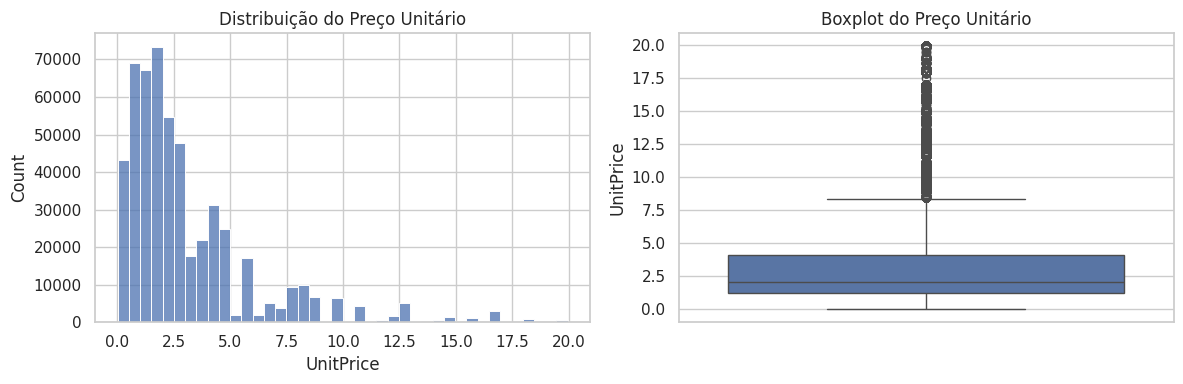

In [9]:
# Histograma
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_filtered = df[(df['UnitPrice'] < 20) & (df['UnitPrice'] > 0)]  # remover outliers extremos para visualização
sns.histplot(df_filtered['UnitPrice'], bins=40, ax=axes[0])
axes[0].set_title('Distribuição do Preço Unitário')

# Boxplot
sns.boxplot(y=df_filtered['UnitPrice'], ax=axes[1])
axes[1].set_title('Boxplot do Preço Unitário')
plt.tight_layout()
plt.show()

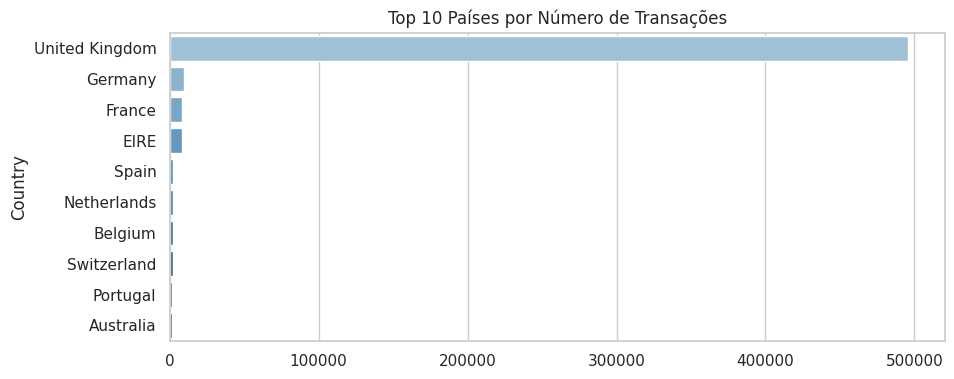

In [ ]:
# Gráfico de barras — top 10 países
top_paises = df['Country'].value_counts().head(10)
plt.figure(figsize=(10,4))
sns.barplot(x=top_paises.values, y=top_paises.index, hue=top_paises.index, palette='Blues_d', legend=False)
plt.title('Top 10 Países por Número de Transações')
plt.show()

### Outros exemplos

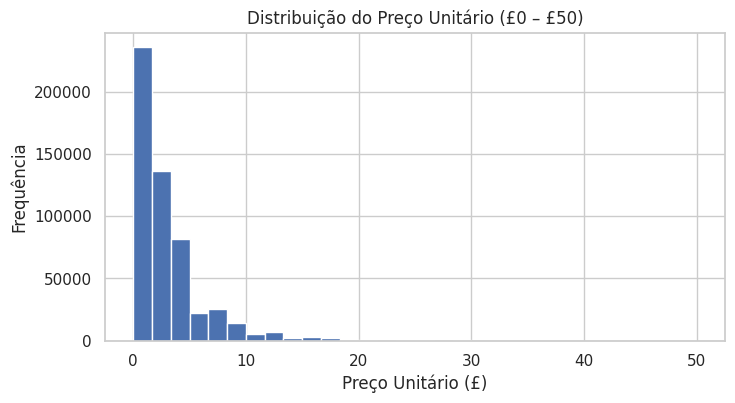

In [11]:
preco_filtrado = df[df['UnitPrice'].between(0, 50)]['UnitPrice']
preco_filtrado.plot(kind='hist', bins=30, edgecolor='white', figsize=(8,4))
plt.title('Distribuição do Preço Unitário (£0 – £50)')
plt.xlabel('Preço Unitário (£)')
plt.ylabel('Frequência')
plt.show()

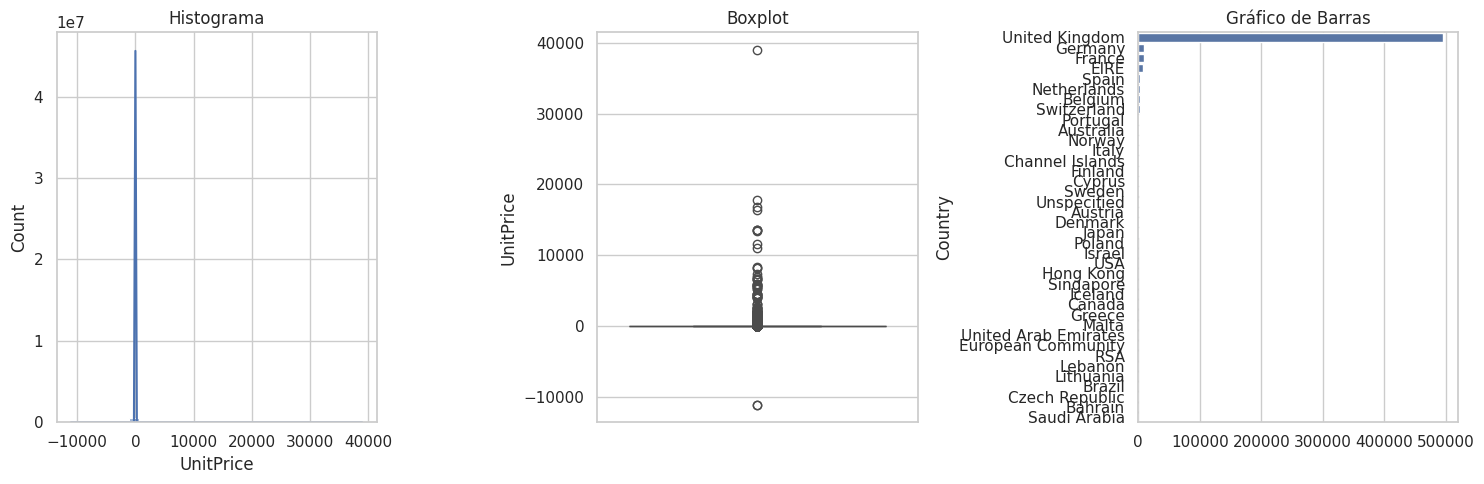

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(df['UnitPrice'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Histograma')

sns.boxplot(y=df['UnitPrice'], ax=axes[1])
axes[1].set_title('Boxplot')

freq = df['Country'].value_counts()
sns.barplot(x=freq.values, y=freq.index, ax=axes[2])
axes[2].set_title('Gráfico de Barras')

plt.tight_layout()
plt.show()